# Quickstart

Train an XGBoost credit model on synthetic data, then ask treecf the core question: *what is the minimal, feasible change that gets this applicant under the approval cutoff?* The search runs on treecf's bundled Rust engine and every answer is float-verified against the model before it is returned.

In [1]:
import numpy as np

rng = np.random.default_rng(42)
n = 6000
names = [
    "income_monthly", "utilization", "n_active_loans", "n_loans_total",
    "max_dpd_30d", "max_dpd_12m", "months_since_last_delinq", "age",
]
income = rng.lognormal(8.3, 0.5, n).round(-1)
utilization = rng.beta(2, 3, n).round(3)
n_total = rng.poisson(4, n).astype(float) + 1
n_active = np.minimum(np.floor(n_total * rng.beta(3, 2, n)), n_total)
dpd_12m = np.floor(rng.exponential(6, n)) * (rng.random(n) < 0.4)
dpd_30d = np.floor(dpd_12m * rng.beta(2, 4, n))
months_delinq = rng.exponential(14, n).round(0)
months_delinq[dpd_12m == 0] = np.nan          # no delinquency -> no record
age = rng.integers(21, 75, n).astype(float)

X = np.column_stack([income, utilization, n_active, n_total,
                     dpd_30d, dpd_12m, months_delinq, age])
risk = (
    -0.9 * np.log(income / 4000)
    + 2.2 * utilization
    + 0.35 * dpd_30d + 0.15 * dpd_12m
    - 0.02 * np.nan_to_num(months_delinq, nan=36.0)
    - 0.015 * age
)
y = (risk + rng.logistic(scale=0.8, size=n) > np.median(risk)).astype(int)
X.shape, y.mean().round(3)

((6000, 8), np.float64(0.534))

In [2]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=120, max_depth=4, learning_rate=0.2,
                          random_state=0)
model.fit(X, y)
model.get_booster().feature_names = list(names)   # domain names for explanations
proba = model.predict_proba(X)[:, 1]
cutoff = 0.30                     # the credit policy's PD cutoff
applicant = X[int(np.argmax(proba))]      # a clearly declined applicant
float(model.predict_proba(applicant.reshape(1, -1))[0, 1])

0.9998112320899963

## Build the explainer

The background sample fits robust per-feature distance normalizers (MAD chain). Two domain constraints: age is immutable here, and the 30-day DPD can never exceed the 12-month DPD.

In [3]:
from treecf import Explainer, Freeze, Target, constraint

exp = Explainer(
    model,
    background=X,
    constraints=[
        Freeze("age"),
        constraint("max_dpd_30d <= max_dpd_12m"),
        constraint("n_active_loans <= n_loans_total"),
    ],
    weights={"income_monthly": 2.0},   # income is hard to change
)
res = exp.explain(applicant, target=Target.probability(range=(0.0, cutoff)),
                  seed=0)
res.proof, res.n_changed, round(res.score_prob, 4)

('heuristic', 3, 0.2908)

In [4]:
res.changes

{'utilization': (0.727, 0.11999998986721039),
 'max_dpd_30d': (12.0, 3.999999761581421),
 'max_dpd_12m': (19.0, 3.999999761581421)}

## Visualize the recommendation

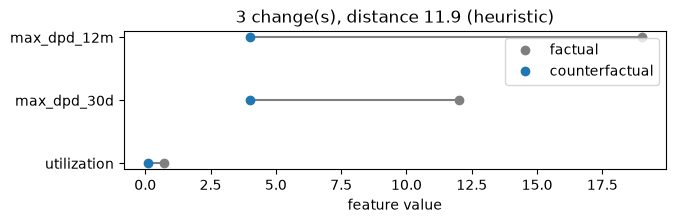

In [5]:
from treecf.viz import plot_changes

plot_changes(res);

**Waterfall** (SHAP-style): each bar is the exact probability delta from one change, applied largest-first; the red line is the policy cutoff. **Effort** shows where the applicant's work goes instead.

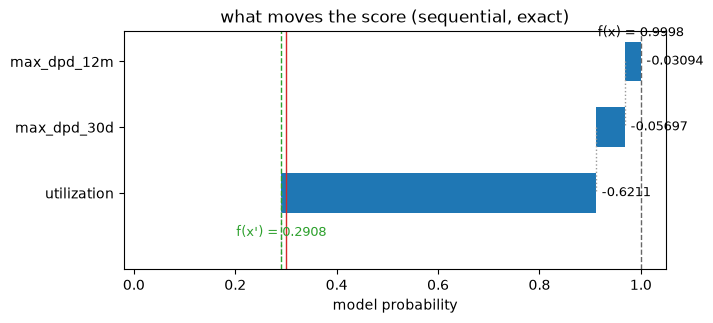

In [6]:
from treecf.viz import plot_effort, plot_waterfall

plot_waterfall(exp, res, target=Target.probability(range=(0.0, cutoff)));

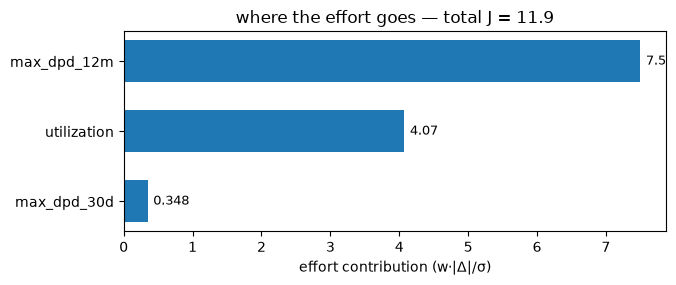

In [7]:
plot_effort(exp, res);